In [1]:
# setting root at top

import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

# EnhancedNormModel 128x128 Image and 5 Conv Blocks
# Using OverSampled high-alert and 0.002 Learning Rate

### Import libraries
* `torch`
* `datasets` and `transforms` from `torchvision` for data Loading.
* `DataLoader` and `WeightedRandomSampler` from `torch.utils.data` for Batching and using data in model.
* `NormModel` from `architectures.NormModel.py`
* `pandas` as `pd`
* `matplotlib.pyplot` as `plt`
* `seaborn` as sns
* `trainer` from `modules.TrainTest`
* `oversampler` from `modules.OverSampler`

In [2]:
# training and architecture
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from architectures.EnhancedNormModel import EnhancedNormModel

# visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#trainer and tester modules
from modules.TrainTest import trainer
from modules.OverSampler import oversampler

### Load datasets for training
* load 64x64 images
* load from `../dataset/final-dataset/train`
* convert to tensor
* make batch_size = 32

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2)
])

train_dataset = datasets.ImageFolder(
    root="../dataset/final-dataset/train",
    transform=train_transform
)

sampler = oversampler(
    dataset=train_dataset,
    oversample_rate= 2
)


In [4]:

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    sampler = sampler
)

### Load datasets for training
* load 64x64 images
* load from `../dataset/final-dataset/train`
* convert to tensor
* make batch_size = 32

In [5]:
valid_transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor()
    ]
)

valid_dataset = datasets.ImageFolder(
    root="../dataset/final-dataset/valid",
    transform=valid_transform
)

valid_dataloader = DataLoader(
    dataset=valid_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

### Use Model for training
Initialize model using 
* `conv_layers = 4`, 
* `initial_output_channel = 16` 
* `initial_image_size = 128`
* `poolings = [1,1,1,1]`
* `normalizations = [1, 1, 1, 1]`,
* `dropouts = [0, 1, 0, 1]`

In [6]:
model = EnhancedNormModel(
    conv_layers=5, 
    normalizations = [1, 1, 1, 1, 1],
    poolings = [1,1,1,1, 1],
    dropouts = [0, 0, 1, 0, 1],
    initial_output_channel=16, 
    initial_image_size=128,
    dropout_p = 0.2
    ).to("cuda")

In [7]:
metrics = trainer(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=valid_dataloader,
    epoch=30,
    lr=0.002,
    print_on=1,
    save_dir="../models/en_norm_img128_c5_lr_0.002_os/",
    save_checkpoints=1,
    checkpoint_name="en_norm_128x128_train_0_",
    early_stop_patience = 8,
    min_delta = 0.01
)

Epoch 1/30 | Train Loss: 1.0006 | Valid Loss: 0.9470
Epoch 2/30 | Train Loss: 0.7731 | Valid Loss: 0.9440
Epoch 3/30 | Train Loss: 0.6619 | Valid Loss: 0.7575
Epoch 4/30 | Train Loss: 0.5868 | Valid Loss: 0.7063
Epoch 5/30 | Train Loss: 0.5312 | Valid Loss: 0.7235
Epoch 6/30 | Train Loss: 0.4783 | Valid Loss: 0.6734
Epoch 7/30 | Train Loss: 0.4350 | Valid Loss: 0.7307
Epoch 8/30 | Train Loss: 0.4057 | Valid Loss: 0.7103
Epoch 9/30 | Train Loss: 0.3781 | Valid Loss: 0.6603
Epoch 10/30 | Train Loss: 0.3672 | Valid Loss: 0.7420
Epoch 11/30 | Train Loss: 0.3399 | Valid Loss: 0.9722
Epoch 12/30 | Train Loss: 0.3204 | Valid Loss: 1.0934
Epoch 13/30 | Train Loss: 0.3171 | Valid Loss: 0.6036
Epoch 14/30 | Train Loss: 0.2949 | Valid Loss: 0.7259
Epoch 15/30 | Train Loss: 0.2840 | Valid Loss: 0.6576
Epoch 16/30 | Train Loss: 0.2732 | Valid Loss: 0.7192
Epoch 17/30 | Train Loss: 0.2599 | Valid Loss: 0.7926
Epoch 18/30 | Train Loss: 0.2563 | Valid Loss: 0.7377
Epoch 19/30 | Train Loss: 0.2402 | Va

## Visualize

Convert metrics to a pd.DataFrame and add epoch column for visualization.

In [11]:
metrics = pd.DataFrame(metrics)
epochs = [i+1 for i  in range(len(metrics))]
metrics["epoch"] = epochs

In [14]:
metrics

,epoch,training_loss,training_accuracy,training_precision,training_recall,training_f1,valid_loss,valid_accuracy,valid_precision,valid_recall,valid_f1
0,1,1.000599,0.536521,0.535510,0.536500,0.535933,0.947013,0.564168,0.578512,0.474197,0.436480
1,2,0.773094,0.658561,0.656933,0.658289,0.657392,0.944000,0.564168,0.586624,0.562190,0.451091
2,3,0.661881,0.718534,0.716793,0.718461,0.717280,0.757498,0.656078,0.647585,0.505456,0.516518
3,4,0.586790,0.755055,0.753958,0.755907,0.754615,0.706341,0.716222,0.616267,0.687407,0.626511
4,5,0.531241,0.780419,0.779390,0.781349,0.780017,0.723473,0.709445,0.615280,0.680458,0.627772
5,6,0.478284,0.804053,0.802366,0.804028,0.802902,0.673406,0.728505,0.630846,0.675518,0.640268
6,7,0.435021,0.825501,0.824118,0.825463,0.824601,0.730742,0.722999,0.651704,0.687810,0.647518
7,8,0.405739,0.835838,0.834548,0.835826,0.834998,0.710263,0.720034,0.628252,0.587425,0.599514
8,9,0.378134,0.848816,0.847357,0.848515,0.847736,0.660299,0.741635,0.665994,0.618218,0.628103
9,10,0.367208,0.855692,0.855072,0.856491,0.855637,0.742020,0.735282,0.655611,0.676366,0.646153


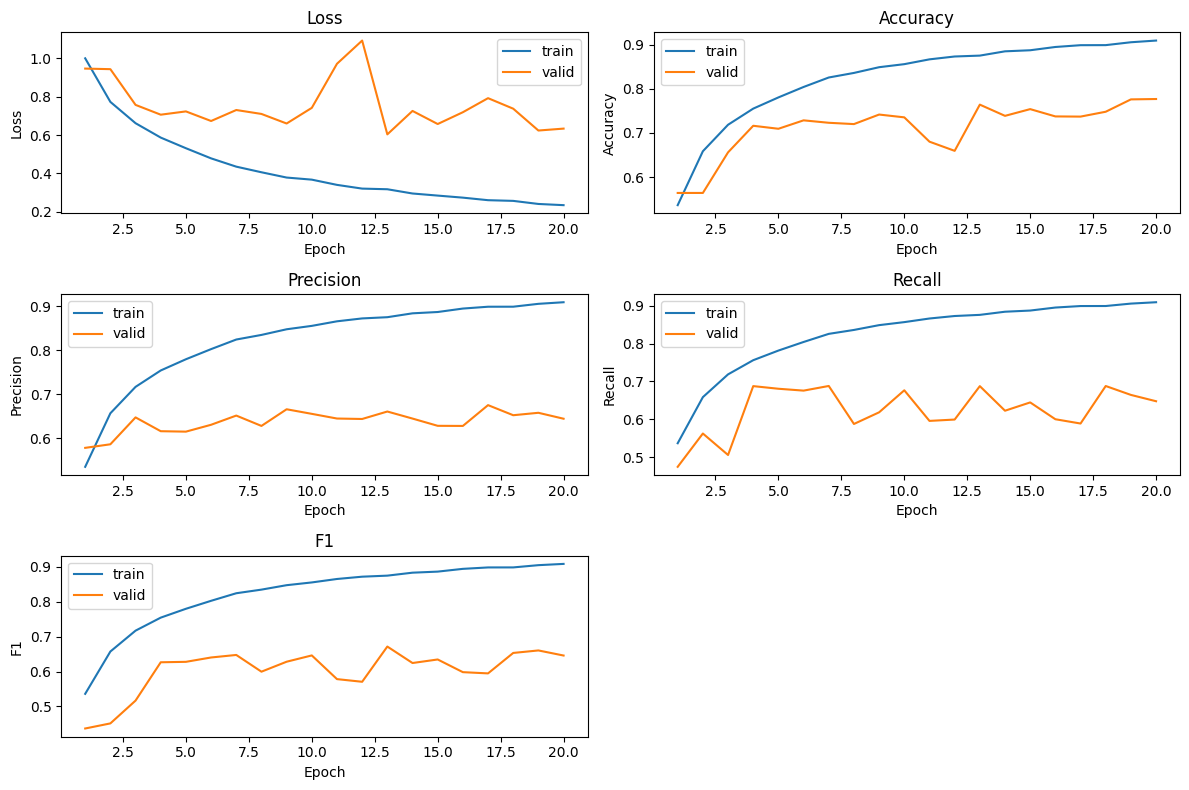

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

to_viz = [
    "loss",
    "accuracy",
    "precision",
    "recall",
    "f1"
]

for i, metric in enumerate(to_viz):

    ax = axes[i]

    sns.lineplot(
        data=metrics,
        x="epoch",
        y=f"training_{metric}",
        ax=ax,
        label="train"
    )

    sns.lineplot(
        data=metrics,
        x="epoch",
        y=f"valid_{metric}",
        ax=ax,
        label="valid"
    )

    ax.set_title(metric.capitalize())
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric.capitalize())

# Hide unused subplot (6th slot)
axes[-1].axis("off")

plt.tight_layout()
plt.show()